In [1]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# Load ARFF
data, meta = arff.loadarff("adult.arff")

df = pd.DataFrame(data)

# Decode byte strings
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode("utf-8")

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst rows:")
display(df.head())

Shape:
(32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Dtypes:
age               float64
workclass          object
fnlwgt            float64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country     object
income             object
dtype: object

First rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [43]:
print(df.isna().sum())

# Sometimes Adult uses '?' instead of NaN
for col in df.columns:
    if df[col].dtype == object:
        n_q = (df[col] == "?").sum()
        if n_q > 0:
            print(f"{col}: {n_q} '?' values")

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
workclass: 1836 '?' values
occupation: 1843 '?' values
native-country: 583 '?' values


In [44]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [45]:
categorical_cols = []
continuous_cols = []

for col in df.columns:
    if df[col].dtype == object:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical:")
print(categorical_cols)

print("\nContinuous:")
print(continuous_cols)

Categorical:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']

Continuous:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [46]:
for col in categorical_cols:
    print(f"\n{col}")
    print(f"unique={df[col].nunique()}")
    print(df[col].value_counts().head())


workclass
unique=9
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Name: count, dtype: int64

education
unique=16
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

marital-status
unique=7
marital-status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

occupation
unique=15
occupation
Prof-specialty     4140
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

relationship
unique=6
relationship
Husband          13193
Not-in-family     8305
Own-child         5068
Unmarried         3446
Wife              1568
Name: count, dtype: int64

race
unique=5
race
White                 27816
Black                  3124
Asian-Pac

In [47]:
display(df[continuous_cols].describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


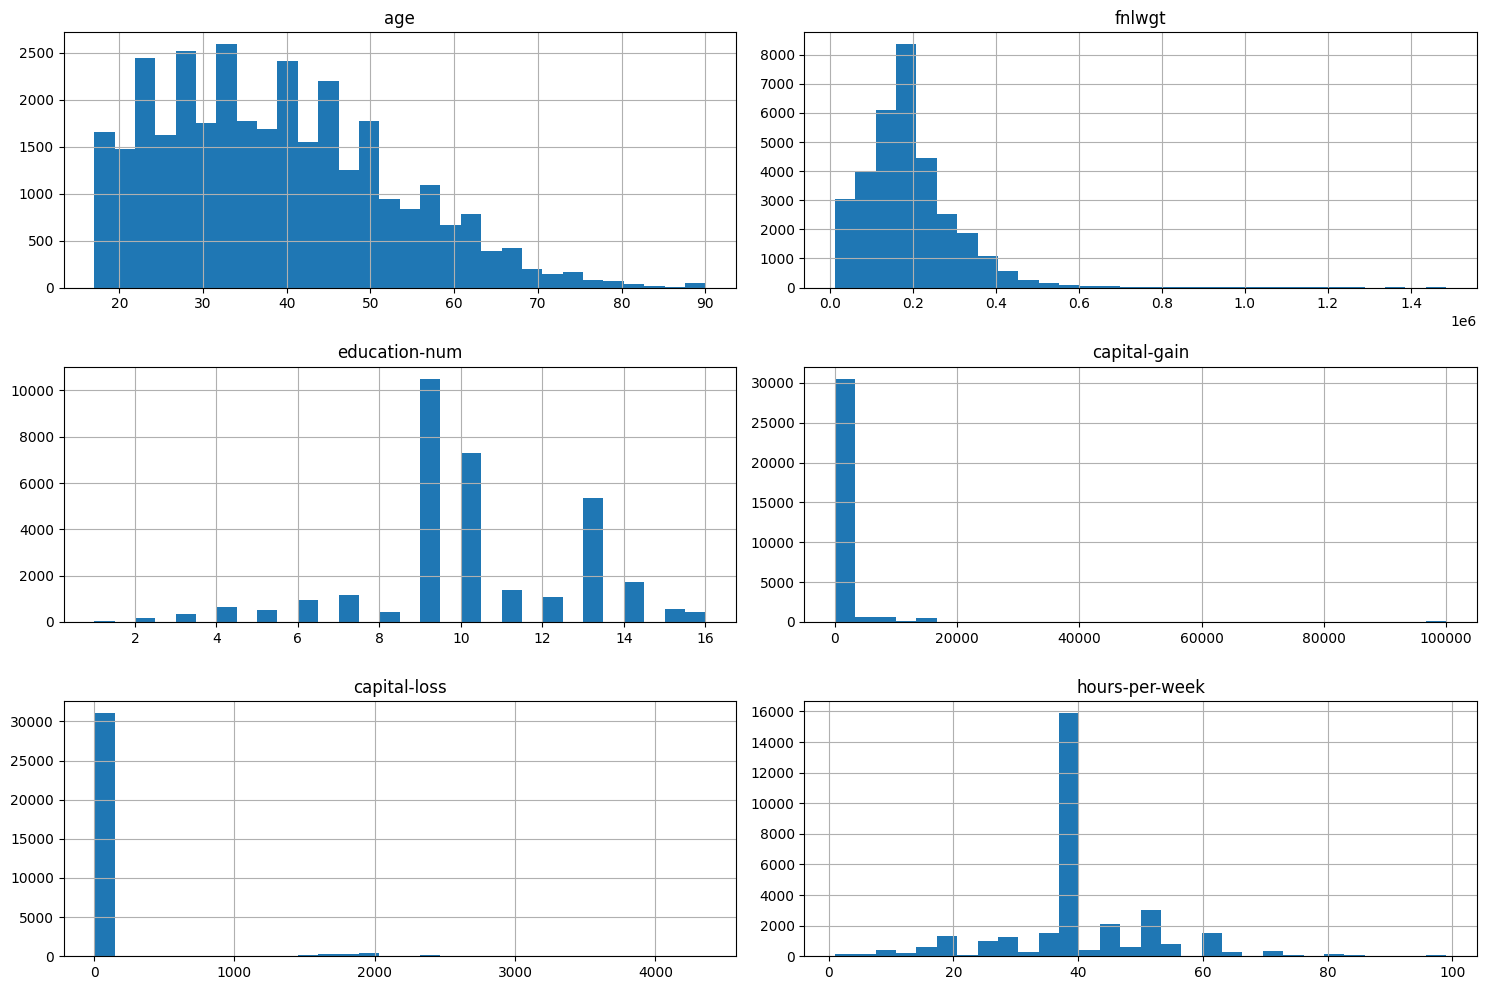

In [48]:
df[continuous_cols].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()

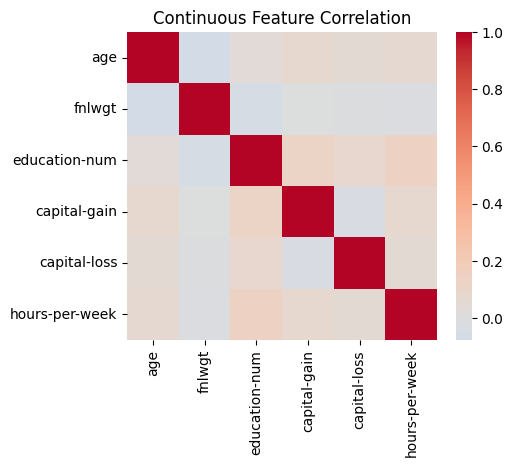

In [49]:
corr = df[continuous_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Continuous Feature Correlation")
plt.show()

# Preprocessing

In [53]:
continuous_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# replace missing values
df = df.replace("?", "Unknown")

target_col = "income"

X = df.drop(columns=[target_col])
y = (df[target_col] == ">50K").astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), continuous_cols),
        (
            "cat",
            OneHotEncoder(
                sparse_output=False,
                handle_unknown="ignore"
            ),
            categorical_cols
        ),
    ]
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (26048, 108)
Test shape: (6513, 108)


In [22]:
y_train.value_counts()

income
0    19775
1     6273
Name: count, dtype: int64

In [23]:
encoder = preprocessor.named_transformers_["cat"]

for col, cats in zip(categorical_cols, encoder.categories_):
    print(col, len(cats))

workclass 9
education 16
marital-status 7
occupation 15
relationship 6
race 5
sex 2
native-country 42


In [55]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

print("Input dim:", X_train_tensor.shape[1])
print("Num batches:", len(train_loader))

Input dim: 108
Num batches: 101


# Models classes

In [56]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

# Main

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = 108
noise_dim = 128

G = Generator(noise_dim, input_dim).to(device)
D = Discriminator(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_G = torch.optim.Adam(
    G.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_D = torch.optim.Adam(
    D.parameters(),
    lr=1e-4,
    betas=(0.5, 0.999)
)

In [58]:
num_epochs = 50

G_losses = []
D_losses = []

for epoch in range(num_epochs):
    epoch_G_loss = 0
    epoch_D_loss = 0

    for (real_batch,) in train_loader:
        real_batch = real_batch.to(device)
        batch_size = real_batch.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -----------------
        # Train Discriminator
        # -----------------
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z).detach()

        D_real = D(real_batch)
        D_fake = D(fake_batch)

        D_loss_real = criterion(D_real, real_labels)
        D_loss_fake = criterion(D_fake, fake_labels)
        D_loss = D_loss_real + D_loss_fake

        optimizer_D.zero_grad()
        D_loss.backward()
        optimizer_D.step()

        # -----------------
        # Train Generator
        # -----------------
        z = torch.randn(batch_size, noise_dim, device=device)
        fake_batch = G(z)

        D_fake = D(fake_batch)

        G_loss = criterion(D_fake, real_labels)

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()

        epoch_D_loss += D_loss.item()
        epoch_G_loss += G_loss.item()

    epoch_D_loss /= len(train_loader)
    epoch_G_loss /= len(train_loader)

    D_losses.append(epoch_D_loss)
    G_losses.append(epoch_G_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"D_loss: {epoch_D_loss:.4f} "
            f"G_loss: {epoch_G_loss:.4f}"
        )
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            D_real_score = torch.sigmoid(D(real_batch)).mean().item()
            D_fake_score = torch.sigmoid(D(fake_batch)).mean().item()

        print(
            f"D(real)={D_real_score:.3f} "
            f"D(fake)={D_fake_score:.3f}"
        )

D(real)=0.501 D(fake)=0.500
Epoch [10/50] D_loss: 1.3810 G_loss: 0.6996
D(real)=0.504 D(fake)=0.499
D(real)=0.496 D(fake)=0.485
Epoch [20/50] D_loss: 1.3660 G_loss: 0.7098
D(real)=0.505 D(fake)=0.510
D(real)=0.505 D(fake)=0.500
Epoch [30/50] D_loss: 1.3534 G_loss: 0.7178
D(real)=0.505 D(fake)=0.486
D(real)=0.512 D(fake)=0.481
Epoch [40/50] D_loss: 1.3535 G_loss: 0.7255
D(real)=0.497 D(fake)=0.526
D(real)=0.522 D(fake)=0.484
Epoch [50/50] D_loss: 1.3388 G_loss: 0.7326
D(real)=0.518 D(fake)=0.480


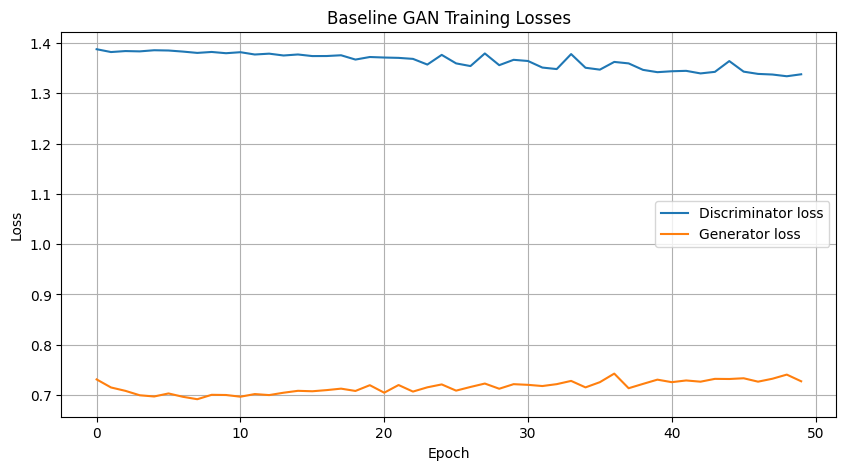

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(D_losses, label="Discriminator loss")
plt.plot(G_losses, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

[ 3.1731832e-01  2.0250700e-01  3.5716966e-04 -1.0418495e-01
 -1.9873402e-01 -1.4358334e-01  1.4373390e-02  1.8184187e-01
 -5.1249586e-02  7.3081255e-01]
[0.91028196 0.80316985 0.9941444  0.04646367 0.02962358 0.9940766
 0.07580847 0.12896052 0.09632301 0.41977802]


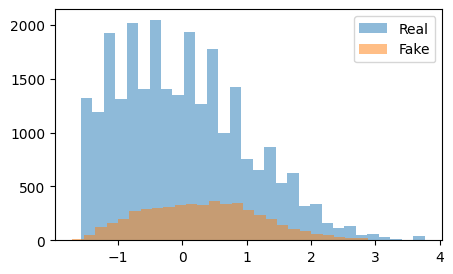

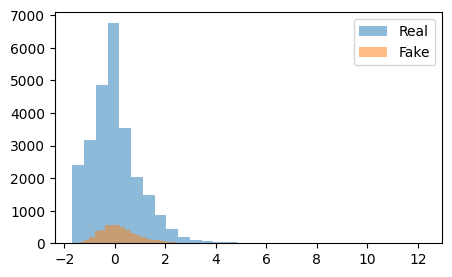

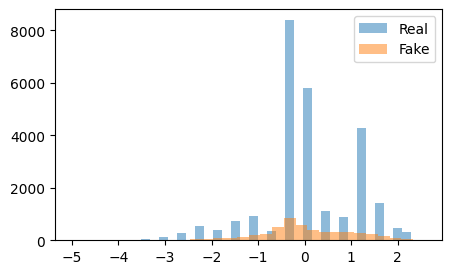

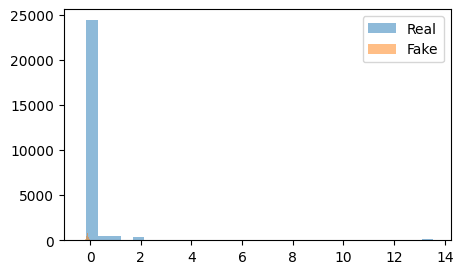

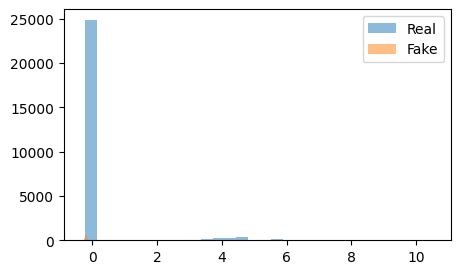

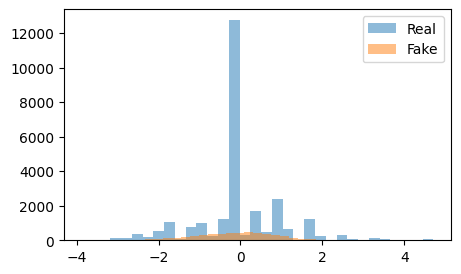

In [31]:
G.eval()

with torch.no_grad():
    z = torch.randn(5000, noise_dim, device=device)
    synth = G(z).cpu().numpy()

print(synth.mean(axis=0)[:10])
print(synth.std(axis=0)[:10])

real_cont = X_train[:, :6]
fake_cont = synth[:, :6]

for i in range(6):
    plt.figure(figsize=(5,3))
    
    plt.hist(
        real_cont[:, i],
        bins=30,
        alpha=0.5,
        label="Real"
    )
    
    plt.hist(
        fake_cont[:, i],
        bins=30,
        alpha=0.5,
        label="Fake"
    )
    
    plt.legend()
    plt.show()

In [28]:
print(fake_cont.std(axis=0))
print(real_cont.std(axis=0))


[1.0562918  0.9968631  0.8446599  0.8033594  0.05704187 0.914403  ]
[1. 1. 1. 1. 1. 1.]


# Creatig training dataset

In [85]:
G.eval()

n_synth = X_train.shape[0]

with torch.no_grad():
    z = torch.randn(n_synth, noise_dim, device=device)
    X_synth_raw = G(z).cpu().numpy()

print(X_synth_raw.shape)

(26048, 108)


In [86]:
import numpy as np
import pandas as pd

def decode_synthetic(X_synth_raw, preprocessor, continuous_cols, categorical_cols):
    scaler = preprocessor.named_transformers_["num"]
    encoder = preprocessor.named_transformers_["cat"]

    n_cont = len(continuous_cols)

    # continuous part
    X_cont_scaled = X_synth_raw[:, :n_cont]
    X_cont = scaler.inverse_transform(X_cont_scaled)

    decoded = pd.DataFrame(X_cont, columns=continuous_cols)

    # categorical part
    start = n_cont

    for col, categories in zip(categorical_cols, encoder.categories_):
        end = start + len(categories)

        logits_block = X_synth_raw[:, start:end]
        idx = np.argmax(logits_block, axis=1)

        decoded[col] = np.array(categories)[idx]

        start = end

    return decoded

In [87]:
df_synth = decode_synthetic(
    X_synth_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

display(df_synth.head())
display(df_synth.describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country
0,15.331485,234782.500000,8.465732,-23.242065,1.908248,32.436974,Private,HS-grad,Never-married,Other-service,Own-child,White,Female,United-States
1,44.567867,257941.390625,11.754906,476.644592,14.582992,45.023026,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,United-States
2,41.657345,91585.960938,12.190663,464.069031,8.678428,46.936478,Private,Some-college,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States
3,42.467140,169462.468750,8.851351,518.472900,12.761237,33.752518,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
4,67.036728,284217.906250,9.276521,15.878052,25.031073,38.258713,Private,HS-grad,Divorced,Sales,Husband,White,Male,United-States


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,30.358694,150229.468750,10.169788,539.462463,12.034827,43.118011
std,12.818159,109039.375000,2.522015,481.493408,10.753448,11.878581
min,-4.271932,-54678.093750,-3.735999,-1779.288696,-31.316881,-24.502106
25%,20.695180,73744.666016,8.883279,251.427383,4.852885,36.180872
50%,28.678828,121434.683594,10.057236,511.820740,11.395934,44.901548
75%,37.858578,200666.132812,11.648683,787.920578,18.713472,51.202386
max,99.865250,910513.062500,20.102329,4912.704102,72.698662,83.822144


In [88]:
for col in categorical_cols:
    print("\n", col)
    print("Real:")
    print(X_train_raw[col].value_counts(normalize=True).head())
    print()
    print("Synthetic:")
    print(df_synth[col].value_counts(normalize=True).head())


 workclass
Real:
workclass
Private             0.694833
Self-emp-not-inc    0.078355
Local-gov           0.065418
Unknown             0.056549
State-gov           0.040425
Name: proportion, dtype: float64

Synthetic:
workclass
Private             0.972128
Self-emp-not-inc    0.010404
Local-gov           0.007371
State-gov           0.004223
Self-emp-inc        0.002342
Name: proportion, dtype: float64

 education
Real:
education
HS-grad         0.321752
Some-college    0.223280
Bachelors       0.163506
Masters         0.053939
Assoc-voc       0.042537
Name: proportion, dtype: float64

Synthetic:
education
HS-grad         0.341792
Some-college    0.272919
Bachelors       0.156442
Masters         0.114443
11th            0.091447
Name: proportion, dtype: float64

 marital-status
Real:
marital-status
Married-civ-spouse    0.460650
Never-married         0.326397
Divorced              0.136671
Separated             0.031711
Widowed               0.031135
Name: proportion, dtype: float64

S

In [89]:
for col in categorical_cols:
    print(
        f"{col}: "
        f"real={X_train_raw[col].nunique()} "
        f"synth={df_synth[col].nunique()}"
    )

workclass: real=9 synth=7
education: real=16 synth=11
marital-status: real=7 synth=5
occupation: real=15 synth=12
relationship: real=6 synth=5
race: real=5 synth=2
sex: real=2 synth=2
native-country: real=42 synth=22


# Detection metric

In [90]:
real_label = 0
fake_label = 1

In [91]:
X_synth = preprocessor.transform(df_synth)

X_det = np.vstack([
    X_train,
    X_synth
])

y_det = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth))
])

In [92]:
X_det.shape

(52096, 108)

In [93]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

aucs = []

for train_idx, test_idx in skf.split(X_det, y_det):

    X_tr = X_det[train_idx]
    X_te = X_det[test_idx]

    y_tr = y_det[train_idx]
    y_te = y_det[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    probs = rf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, probs)

    aucs.append(auc)

print("Detection AUCs:", aucs)
print("Mean Detection AUC:", np.mean(aucs))

Detection AUCs: [1.0, 0.9999999764185115, 1.0, 1.0]
Mean Detection AUC: 0.9999999941046278


In [94]:
X_det_cont = np.vstack([
    X_train[:, :6],
    X_synth[:, :6]
])

y_det = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth))
])

# same RF cross validation

In [96]:
cat_part = X_synth[:, 6:]

always_zero = np.where((cat_part == 0).all(axis=0))[0]

print("Always zero categorical columns:", len(always_zero))

Always zero categorical columns: 36


In [97]:
start = 6

for col, cats in zip(
    categorical_cols,
    preprocessor.named_transformers_["cat"].categories_
):
    end = start + len(cats)

    block = X_synth[:, start:end]

    active = np.sum(block.sum(axis=0) > 0)

    print(
        f"{col}: "
        f"{active}/{len(cats)} categories generated"
    )

    start = end

workclass: 7/9 categories generated
education: 11/16 categories generated
marital-status: 5/7 categories generated
occupation: 12/15 categories generated
relationship: 5/6 categories generated
race: 2/5 categories generated
sex: 2/2 categories generated
native-country: 22/42 categories generated


# Efficacy

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# Real baseline
rf_real = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_real.fit(X_train, y_train)

real_probs = rf_real.predict_proba(X_test)[:, 1]
auc_real = roc_auc_score(y_test, real_probs)

print("AUC real train -> real test:", auc_real)

AUC real train -> real test: 0.9079627819277357


In [99]:
rng = np.random.default_rng(42)

y_synth = rng.choice(
    y_train,
    size=len(X_synth),
    replace=True
)

rf_synth = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_synth.fit(X_synth, y_synth)

synth_probs = rf_synth.predict_proba(X_test)[:, 1]
auc_synth = roc_auc_score(y_test, synth_probs)

efficacy = auc_synth / auc_real

print("AUC synthetic train -> real test:", auc_synth)
print("Efficacy:", efficacy)

AUC synthetic train -> real test: 0.6113670657848578
Efficacy: 0.6733393460102378


# CGAN

In [100]:
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

cgan_dataset = TensorDataset(X_train_tensor, y_train_tensor)

cgan_loader = DataLoader(
    cgan_dataset,
    batch_size=256,
    shuffle=True,
    drop_last=True
)

In [101]:
import torch.nn as nn
import torch.nn.functional as F

class ConditionalGenerator(nn.Module):
    def __init__(self, noise_dim, condition_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim + condition_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim)
        )

    def forward(self, z, y):
        y_onehot = F.one_hot(y, num_classes=2).float()
        x = torch.cat([z, y_onehot], dim=1)
        return self.net(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, input_dim, condition_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim + condition_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1)
        )

    def forward(self, x, y):
        y_onehot = F.one_hot(y, num_classes=2).float()
        x = torch.cat([x, y_onehot], dim=1)
        return self.net(x)

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dim = X_train.shape[1]
noise_dim = 128
condition_dim = 2

cG = ConditionalGenerator(noise_dim, condition_dim, input_dim).to(device)
cD = ConditionalDiscriminator(input_dim, condition_dim).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer_cG = torch.optim.Adam(
    cG.parameters(),
    lr=2e-4,
    betas=(0.5, 0.999)
)

optimizer_cD = torch.optim.Adam(
    cD.parameters(),
    lr=1e-4,
    betas=(0.5, 0.999)
)

In [103]:
num_epochs = 50

cG_losses = []
cD_losses = []

for epoch in range(num_epochs):
    epoch_cG_loss = 0
    epoch_cD_loss = 0

    for real_batch, y_batch in cgan_loader:
        real_batch = real_batch.to(device)
        y_batch = y_batch.to(device)

        batch_size = real_batch.size(0)

        real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train Conditional Discriminator
        # -------------------------
        z = torch.randn(batch_size, noise_dim, device=device)

        fake_batch = cG(z, y_batch).detach()

        cD_real = cD(real_batch, y_batch)
        cD_fake = cD(fake_batch, y_batch)

        cD_loss_real = criterion(cD_real, real_labels)
        cD_loss_fake = criterion(cD_fake, fake_labels)

        cD_loss = cD_loss_real + cD_loss_fake

        optimizer_cD.zero_grad()
        cD_loss.backward()
        optimizer_cD.step()

        # -------------------------
        # Train Conditional Generator
        # -------------------------
        for _ in range(2):
            z = torch.randn(batch_size, noise_dim, device=device)

            fake_batch = cG(z, y_batch)

            cD_fake = cD(fake_batch, y_batch)

            cG_loss = criterion(cD_fake, real_labels)

            optimizer_cG.zero_grad()
            cG_loss.backward()
            optimizer_cG.step()

        epoch_cD_loss += cD_loss.item()
        epoch_cG_loss += cG_loss.item()

    epoch_cD_loss /= len(cgan_loader)
    epoch_cG_loss /= len(cgan_loader)

    cD_losses.append(epoch_cD_loss)
    cG_losses.append(epoch_cG_loss)

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            cD_real_score = torch.sigmoid(cD(real_batch, y_batch)).mean().item()
            cD_fake_score = torch.sigmoid(cD(fake_batch, y_batch)).mean().item()

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"cD_loss: {epoch_cD_loss:.4f} "
            f"cG_loss: {epoch_cG_loss:.4f} "
            f"cD(real): {cD_real_score:.3f} "
            f"cD(fake): {cD_fake_score:.3f}"
        )

Epoch [10/50] cD_loss: 1.3772 cG_loss: 0.7708 cD(real): 0.453 cD(fake): 0.454
Epoch [20/50] cD_loss: 1.3734 cG_loss: 0.7841 cD(real): 0.444 cD(fake): 0.448
Epoch [30/50] cD_loss: 1.3726 cG_loss: 0.7828 cD(real): 0.454 cD(fake): 0.444
Epoch [40/50] cD_loss: 1.3725 cG_loss: 0.7887 cD(real): 0.456 cD(fake): 0.446
Epoch [50/50] cD_loss: 1.3678 cG_loss: 0.7907 cD(real): 0.453 cD(fake): 0.451


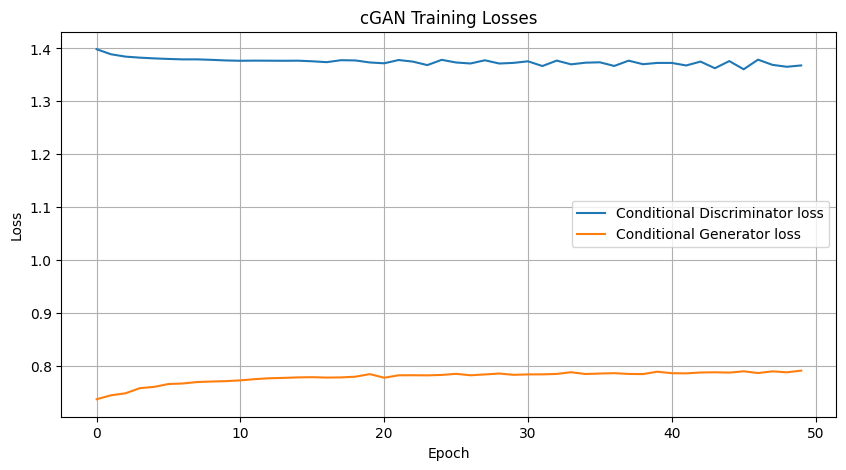

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cD_losses, label="Conditional Discriminator loss")
plt.plot(cG_losses, label="Conditional Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("cGAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

In [105]:
cG.eval()

n_synth = X_train.shape[0]

rng = np.random.default_rng(42)

y_synth_cgan_np = rng.choice(
    y_train.values,
    size=n_synth,
    replace=True
)

y_synth_cgan = torch.tensor(
    y_synth_cgan_np,
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    z = torch.randn(n_synth, noise_dim, device=device)
    X_synth_cgan_raw = cG(z, y_synth_cgan).cpu().numpy()

df_synth_cgan = decode_synthetic(
    X_synth_cgan_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_cgan = preprocessor.transform(df_synth_cgan)

print(X_synth_cgan.shape)
print(pd.Series(y_synth_cgan_np).value_counts(normalize=True))

(26048, 108)
0    0.753762
1    0.246238
Name: proportion, dtype: float64


In [106]:
for col in categorical_cols:
    print(
        f"{col}: "
        f"real={X_train_raw[col].nunique()} "
        f"cGAN={df_synth_cgan[col].nunique()}"
    )

workclass: real=9 cGAN=6
education: real=16 cGAN=14
marital-status: real=7 cGAN=4
occupation: real=15 cGAN=14
relationship: real=6 cGAN=6
race: real=5 cGAN=3
sex: real=2 cGAN=2
native-country: real=42 cGAN=2


In [107]:
X_det_cgan = np.vstack([
    X_train,
    X_synth_cgan
])

y_det_cgan = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_synth_cgan))
])

In [108]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

aucs = []

for train_idx, test_idx in skf.split(X_det_cgan, y_det_cgan):

    X_tr = X_det_cgan[train_idx]
    X_te = X_det_cgan[test_idx]

    y_tr = y_det_cgan[train_idx]
    y_te = y_det_cgan[test_idx]

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_tr, y_tr)

    probs = rf.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, probs)

    aucs.append(auc)

print("Detection AUCs:", aucs)
print("Mean Detection AUC:", np.mean(aucs))

Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


In [109]:
rng = np.random.default_rng(42)


rf_synth = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_synth.fit(X_synth_cgan, y_synth_cgan_np)

synth_probs = rf_synth.predict_proba(X_test)[:, 1]
auc_synth = roc_auc_score(y_test, synth_probs)

efficacy = auc_synth / auc_real

print("AUC synthetic train -> real test:", auc_synth)
print("Efficacy:", efficacy)

AUC synthetic train -> real test: 0.8480919579661996
Efficacy: 0.9340602663972396


# Gumble Softmax

In [110]:
cat_dims = [
    len(cats)
    for cats in preprocessor.named_transformers_["cat"].categories_
]

print(cat_dims)
print(sum(cat_dims))

[9, 16, 7, 15, 6, 5, 2, 42]
102


In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class StructuredGenerator(nn.Module):
    def __init__(
        self,
        noise_dim,
        n_cont,
        cat_dims,
        hidden_dim=512,
        cat_mode="softmax",
        tau=1.0
    ):
        super().__init__()

        self.n_cont = n_cont
        self.cat_dims = cat_dims
        self.cat_mode = cat_mode
        self.tau = tau

        output_dim = n_cont + sum(cat_dims)

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z, return_soft=False):
        raw = self.net(z)

        cont = raw[:, :self.n_cont]
        cat_logits = raw[:, self.n_cont:]

        processed_blocks = []
        soft_blocks = []

        start = 0

        for dim in self.cat_dims:
            end = start + dim
            logits = cat_logits[:, start:end]

            probs = F.softmax(logits, dim=1)
            soft_blocks.append(probs)

            if self.cat_mode == "softmax":
                block = probs

            elif self.cat_mode == "gumbel":
                block = F.gumbel_softmax(
                    logits,
                    tau=self.tau,
                    hard=True,
                    dim=1
                )

            else:
                raise ValueError(f"Unknown cat_mode: {self.cat_mode}")

            processed_blocks.append(block)

            start = end

        out = torch.cat([cont] + processed_blocks, dim=1)

        if return_soft:
            soft_out = torch.cat([cont] + soft_blocks, dim=1)
            return out, soft_out

        return out

In [112]:
def train_structured_gan(
    cat_mode,
    train_loader,
    input_dim,
    noise_dim,
    n_cont,
    cat_dims,
    device,
    num_epochs=50,
    tau=1.0,
    g_updates=2,
    lr_g=2e-4,
    lr_d=1e-4
):
    G = StructuredGenerator(
        noise_dim=noise_dim,
        n_cont=n_cont,
        cat_dims=cat_dims,
        cat_mode=cat_mode,
        tau=tau
    ).to(device)

    D = Discriminator(input_dim).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = torch.optim.Adam(
        G.parameters(),
        lr=lr_g,
        betas=(0.5, 0.999)
    )

    optimizer_D = torch.optim.Adam(
        D.parameters(),
        lr=lr_d,
        betas=(0.5, 0.999)
    )

    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        epoch_G_loss = 0
        epoch_D_loss = 0

        for (real_batch,) in train_loader:
            real_batch = real_batch.to(device)
            batch_size = real_batch.size(0)

            real_labels = torch.empty(batch_size, 1, device=device).uniform_(0.8, 1.0)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # Train D
            z = torch.randn(batch_size, noise_dim, device=device)
            fake_batch = G(z).detach()

            D_real = D(real_batch)
            D_fake = D(fake_batch)

            D_loss = (
                criterion(D_real, real_labels)
                + criterion(D_fake, fake_labels)
            )

            optimizer_D.zero_grad()
            D_loss.backward()
            optimizer_D.step()

            # Train G
            for _ in range(g_updates):
                z = torch.randn(batch_size, noise_dim, device=device)
                fake_batch = G(z)

                D_fake = D(fake_batch)
                G_loss = criterion(D_fake, real_labels)

                optimizer_G.zero_grad()
                G_loss.backward()
                optimizer_G.step()

            epoch_D_loss += D_loss.item()
            epoch_G_loss += G_loss.item()

        epoch_D_loss /= len(train_loader)
        epoch_G_loss /= len(train_loader)

        D_losses.append(epoch_D_loss)
        G_losses.append(epoch_G_loss)

        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                D_real_score = torch.sigmoid(D(real_batch)).mean().item()
                D_fake_score = torch.sigmoid(D(fake_batch)).mean().item()

            print(
                f"[{cat_mode}] Epoch [{epoch+1}/{num_epochs}] "
                f"D_loss={epoch_D_loss:.4f} "
                f"G_loss={epoch_G_loss:.4f} "
                f"D(real)={D_real_score:.3f} "
                f"D(fake)={D_fake_score:.3f}"
            )

    return G, D, G_losses, D_losses

In [113]:
n_cont = len(continuous_cols)
input_dim = X_train.shape[1]
noise_dim = 128

G_softmax, D_softmax, G_softmax_losses, D_softmax_losses = train_structured_gan(
    cat_mode="softmax",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0
)

[softmax] Epoch [10/50] D_loss=1.1408 G_loss=1.0688 D(real)=0.461 D(fake)=0.386
[softmax] Epoch [20/50] D_loss=1.0936 G_loss=1.1279 D(real)=0.573 D(fake)=0.340
[softmax] Epoch [30/50] D_loss=1.0316 G_loss=1.2625 D(real)=0.622 D(fake)=0.308
[softmax] Epoch [40/50] D_loss=0.9914 G_loss=1.3600 D(real)=0.627 D(fake)=0.328
[softmax] Epoch [50/50] D_loss=1.0647 G_loss=1.2401 D(real)=0.633 D(fake)=0.263


In [114]:
G_gumbel, D_gumbel, G_gumbel_losses, D_gumbel_losses = train_structured_gan(
    cat_mode="gumbel",
    train_loader=train_loader,
    input_dim=input_dim,
    noise_dim=noise_dim,
    n_cont=n_cont,
    cat_dims=cat_dims,
    device=device,
    num_epochs=50,
    tau=1.0
)

[gumbel] Epoch [10/50] D_loss=1.3622 G_loss=0.7912 D(real)=0.450 D(fake)=0.439
[gumbel] Epoch [20/50] D_loss=1.3227 G_loss=0.8409 D(real)=0.474 D(fake)=0.387
[gumbel] Epoch [30/50] D_loss=1.3193 G_loss=0.8603 D(real)=0.488 D(fake)=0.417
[gumbel] Epoch [40/50] D_loss=1.2994 G_loss=0.8573 D(real)=0.493 D(fake)=0.412
[gumbel] Epoch [50/50] D_loss=1.2812 G_loss=0.8809 D(real)=0.500 D(fake)=0.399


In [115]:
def generate_structured_synthetic(G, n_samples, noise_dim, device):
    G.eval()

    with torch.no_grad():
        z = torch.randn(n_samples, noise_dim, device=device)
        X_raw, X_soft = G(z, return_soft=True)

    return X_raw.cpu().numpy(), X_soft.cpu().numpy()

In [116]:
X_softmax_raw, X_softmax_soft = generate_structured_synthetic(
    G_softmax,
    X_train.shape[0],
    noise_dim,
    device
)

X_gumbel_raw, X_gumbel_soft = generate_structured_synthetic(
    G_gumbel,
    X_train.shape[0],
    noise_dim,
    device
)

In [117]:
df_synth_softmax = decode_synthetic(
    X_softmax_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_softmax = preprocessor.transform(df_synth_softmax)


df_synth_gumbel = decode_synthetic(
    X_gumbel_raw,
    preprocessor,
    continuous_cols,
    categorical_cols
)

X_synth_gumbel = preprocessor.transform(df_synth_gumbel)

In [118]:
def print_category_coverage(df_synth, name):
    print(name)

    for col in categorical_cols:
        print(
            f"{col}: "
            f"real={X_train_raw[col].nunique()} "
            f"{name}={df_synth[col].nunique()}"
        )

In [119]:
print_category_coverage(df_synth_softmax, "softmax")
print_category_coverage(df_synth_gumbel, "gumbel")

softmax
workclass: real=9 softmax=2
education: real=16 softmax=4
marital-status: real=7 softmax=3
occupation: real=15 softmax=5
relationship: real=6 softmax=4
race: real=5 softmax=1
sex: real=2 softmax=2
native-country: real=42 softmax=1
gumbel
workclass: real=9 gumbel=7
education: real=16 gumbel=14
marital-status: real=7 gumbel=7
occupation: real=15 gumbel=15
relationship: real=6 gumbel=6
race: real=5 gumbel=5
sex: real=2 gumbel=2
native-country: real=42 gumbel=5


In [121]:
def run_detection_auc(X_real, X_synth, n_splits=4, random_state=42):
    X_det = np.vstack([X_real, X_synth])

    y_det = np.concatenate([
        np.zeros(len(X_real)),
        np.ones(len(X_synth))
    ])

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    aucs = []

    for train_idx, test_idx in skf.split(X_det, y_det):
        X_tr = X_det[train_idx]
        X_te = X_det[test_idx]

        y_tr = y_det[train_idx]
        y_te = y_det[test_idx]

        rf = RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1
        )

        rf.fit(X_tr, y_tr)

        probs = rf.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, probs)

        aucs.append(auc)

    print("Detection AUCs:", aucs)
    print("Mean Detection AUC:", np.mean(aucs))

    return aucs, np.mean(aucs)

In [122]:
print("Softmax Detection")
run_detection_auc(X_train, X_synth_softmax)

print("Gumbel Detection")
run_detection_auc(X_train, X_synth_gumbel)

Softmax Detection
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0
Gumbel Detection
Detection AUCs: [1.0, 1.0, 1.0, 1.0]
Mean Detection AUC: 1.0


([1.0, 1.0, 1.0, 1.0], np.float64(1.0))

In [123]:
for name, Xs in [
    ("softmax", X_synth_softmax),
    ("gumbel", X_synth_gumbel),
]:
    always_zero = np.where((Xs[:, 6:] == 0).all(axis=0))[0]
    print(name, "always-zero categorical columns:", len(always_zero))

softmax always-zero categorical columns: 80
gumbel always-zero categorical columns: 41


In [124]:
print("Gumbel continuous-only detection")
run_detection_auc(X_train[:, :6], X_synth_gumbel[:, :6])

Gumbel continuous-only detection
Detection AUCs: [1.0, 1.0, 1.0, 0.9999999528370229]
Mean Detection AUC: 0.9999999882092557


([1.0, 1.0, 1.0, 0.9999999528370229], np.float64(0.9999999882092557))

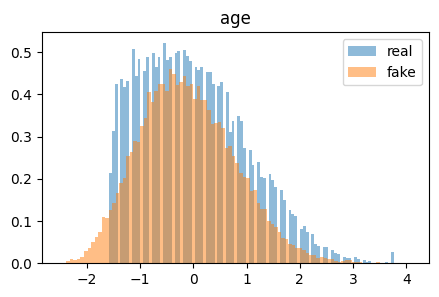

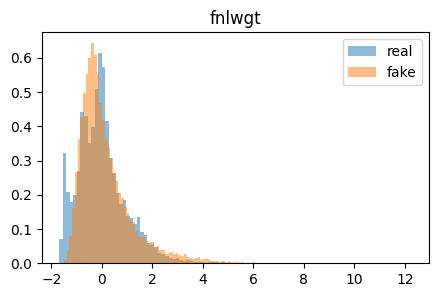

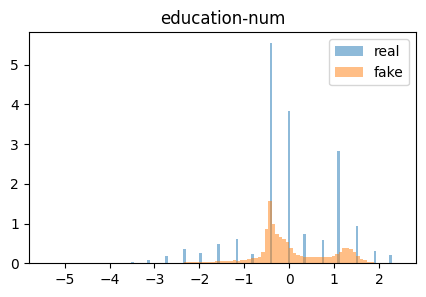

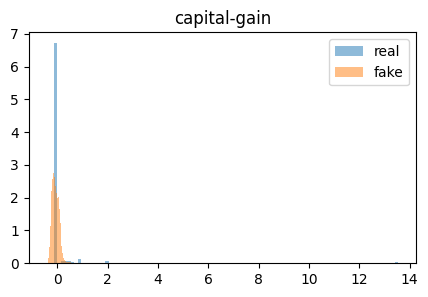

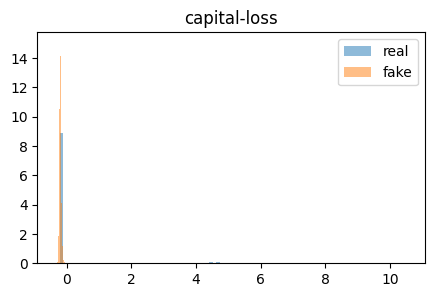

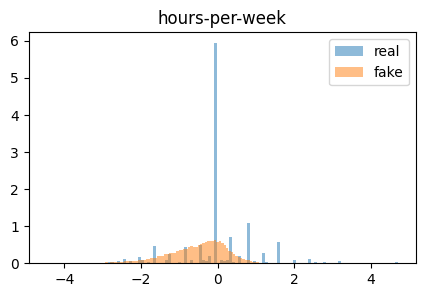

In [125]:
for i, col in enumerate(continuous_cols):
    plt.figure(figsize=(5,3))

    plt.hist(
        X_train[:, i],
        bins=100,
        alpha=0.5,
        label="real",
        density=True
    )

    plt.hist(
        X_synth_gumbel[:, i],
        bins=100,
        alpha=0.5,
        label="fake",
        density=True
    )

    plt.title(col)
    plt.legend()
    plt.show()